In [1]:
import pandas as pd
import numpy as np

In [2]:
# 1. Load the data

df = pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# AT --> Tempr in PowerPlant
# V --> Vaccum
# AP --> Pressure
# RH --> Humidity

# PE --> Produced Energy

df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [3]:
X = df.drop("PE" , axis = 1)
y = df["PE"]

In [4]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [5]:
# Split the data
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size = 0.2 , random_state = 42
)

In [8]:
df.shape

(9568, 5)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled , dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values , dtype = torch.float32).view(-1 , 1)

X_test_tensor = torch.tensor(X_test_scaled , dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values , dtype = torch.float32).view(-1 , 1)

In [8]:
# Architecture --> Layers --> Neurons
from torch.utils.data import TensorDataset , DataLoader

train_dataset =  TensorDataset(X_train_tensor , y_train_tensor)
test_dataset = TensorDataset(X_test_tensor , y_test_tensor)

In [9]:
train_loader = DataLoader(train_dataset , batch_size = 32 , shuffle = True)
test_loader =  DataLoader(test_dataset , batch_size = 32 , shuffle = True)

# Deep Learning

In [10]:
# ANN Model --> Build in form of class --> Build on top of nn. Module


# Build Our Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN , self).__init__()

        self.model = nn.Sequential(
            
            # 1st Hidden Layer
            nn.Linear(X_train.shape[1] , 6), # (No. of inputs , No. of outputs)
            nn.ReLU(),
    
            # 2nd Hidden Layer
            nn.Linear(6 , 6),
            nn.ReLU(),
    
            #output layer
            nn.Linear(6 , 1),
        )

    def forward(self , x):
        return self.model(x)

In [11]:
import torch.optim as optim

model = ANN()

#Loss , Optimizer

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [12]:
# Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for xb , yb in train_loader:
        # xb = features of one batch , yb = labels of 1 batch
        optimizer.zero_grad()
        
        outputs = model(xb) # forward prop .... predicted outputs for this batch
        loss = criterion(outputs , yb) # compute loss
        loss.backward() # back prop.. compute gradients
        optimizer.step() # params update

        running_loss += loss.item() # loss is a tensor => py float

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # Validation --> No need to adjust weights , bias so no gradient calculation took place
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): # no gradient calculation
        for xb , yb in test_loader:
             outputs = model(xb)
             loss = criterion(outputs , yb)
             running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch + 1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict() , "best_model.pt") # .pt or .pth
        
        

epoch 1/100 ==> train loss = 206292.38854166667 & val loss = 204798.984375
epoch 2/100 ==> train loss = 199241.08483072917 & val loss = 189304.453125
epoch 3/100 ==> train loss = 170680.1322265625 & val loss = 147571.1875
epoch 4/100 ==> train loss = 119255.27893880209 & val loss = 90139.609375
epoch 5/100 ==> train loss = 64751.82379557292 & val loss = 43207.46484375
epoch 6/100 ==> train loss = 30314.39598388672 & val loss = 21371.25
epoch 7/100 ==> train loss = 17377.160404459635 & val loss = 14516.9619140625
epoch 8/100 ==> train loss = 12958.313979085286 & val loss = 11391.80859375
epoch 9/100 ==> train loss = 10337.12524210612 & val loss = 9108.9912109375
epoch 10/100 ==> train loss = 8226.550602213541 & val loss = 7135.5439453125
epoch 11/100 ==> train loss = 6345.470649210612 & val loss = 5392.4150390625
epoch 12/100 ==> train loss = 4709.727733357748 & val loss = 3934.486083984375
epoch 13/100 ==> train loss = 3353.3525619506836 & val loss = 2745.715576171875
epoch 14/100 ==> 

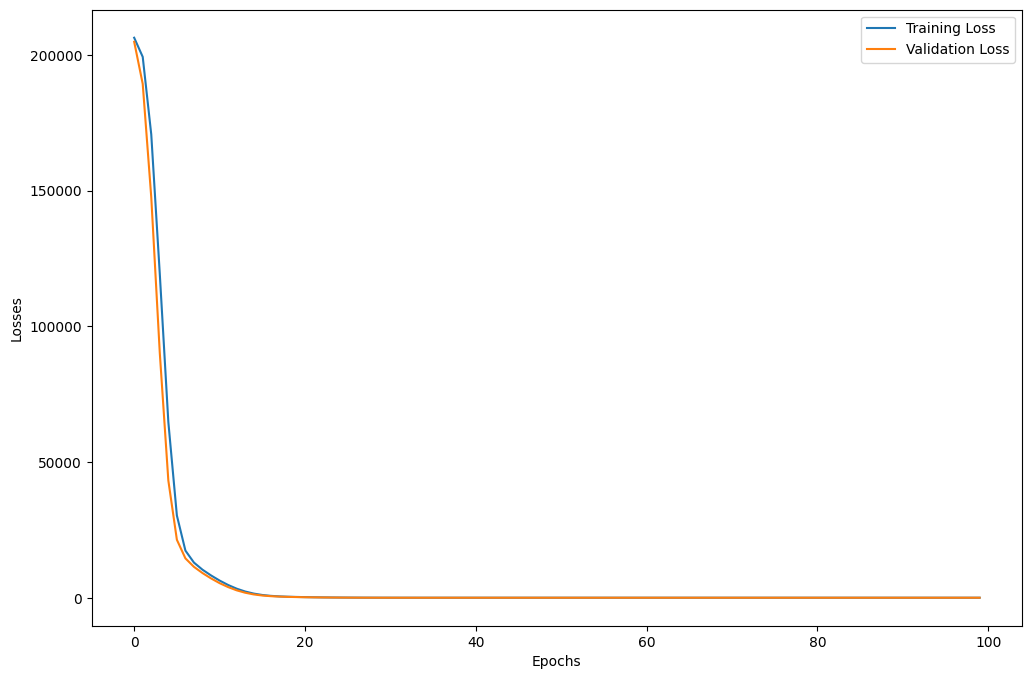

In [13]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss" : train_losses,
    "Validation Loss" : val_losses
})

plt.figure(figsize = (12 , 8))
plt.plot(loss_df["Training Loss"] , label = "Training Loss")
plt.plot(loss_df["Validation Loss"] , label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [14]:
# Loading the best Model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [16]:
# Evalution model

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds , y_train_tensor)
    test_mse_loss = criterion(test_preds , y_test_tensor)

print(f"Training MSE : {train_mse_loss.item()}")
print(f"Test MSE : {test_mse_loss.item()}")

Training MSE : 20.248947143554688
Test MSE : 18.657215118408203


In [18]:
from sklearn.metrics import r2_score

print(f"r2 score : {r2_score(y_test , test_preds)}")

r2 score : 0.9347978429618996


In [23]:
predicted_df = pd.DataFrame(test_preds.numpy() , columns = ["Predicted Values"])
actual_df = pd.DataFrame(y_test.values , columns = ["Actual Values"])

pd.concat([predicted_df , actual_df] , axis = 1)

,Predicted Values,Actual Values
0,435.276825,433.27
1,437.116882,438.16
2,461.381073,458.42
3,476.313110,480.82
4,435.533936,441.41
...,...,...
1909,451.335022,456.70
1910,431.766357,438.04
1911,467.450806,467.80
1912,431.250916,437.14
